In [3]:
import pandas as pd
import numpy as np

# Visualization
import seaborn as sns
import matplotlib.pyplot as plt

# ML
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score

Q1:Load the data. Explore columns data types and report the number of missing values before and after conversion. also fix them with proper imputation methodsLoad CSV → Check dtypes → Count missing values → fix them with proper imputation methods → Report before/after counts

In [4]:
titanic = sns.load_dataset('titanic')
titanic.head()

,survived,pclass,sex,age,sibsp,parch,fare,embarked,class,who,adult_male,deck,embark_town,alive,alone
0,0,3,male,22.0,1,0,7.2500,S,Third,man,True,NaN,Southampton,no,False
1,1,1,female,38.0,1,0,71.2833,C,First,woman,False,C,Cherbourg,yes,False
2,1,3,female,26.0,0,0,7.9250,S,Third,woman,False,NaN,Southampton,yes,True
3,1,1,female,35.0,1,0,53.1000,S,First,woman,False,C,Southampton,yes,False
4,0,3,male,35.0,0,0,8.0500,S,Third,man,True,NaN,Southampton,no,True


In [5]:
titanic.dtypes

survived          int64
pclass            int64
sex                 str
age             float64
sibsp             int64
parch             int64
fare            float64
embarked            str
class          category
who                 str
adult_male         bool
deck           category
embark_town         str
alive               str
alone              bool
dtype: object

In [6]:
titanic.isnull().sum()

survived         0
pclass           0
sex              0
age            177
sibsp            0
parch            0
fare             0
embarked         2
class            0
who              0
adult_male       0
deck           688
embark_town      2
alive            0
alone            0
dtype: int64

In [7]:
titanic['age'] = titanic['age'].fillna(titanic['age'].median(), inplace=True)
titanic['deck'] = titanic['deck'].fillna(titanic['deck'].mode()[0], inplace=True)
titanic['embarked'] = titanic['embarked'].fillna(titanic['embarked'].mode()[0], inplace=True)
titanic['embark_town'] = titanic['embark_town'].fillna(titanic['embark_town'].mode()[0], inplace=True)

C:\Users\Laptop Links\AppData\Local\Temp\ipykernel_12208\1515767228.py:1: ChainedAssignmentError: A value is being set on a copy of a DataFrame or Series through chained assignment using an inplace method.
Such inplace method never works to update the original DataFrame or Series, because the intermediate object on which we are setting values always behaves as a copy (due to Copy-on-Write).

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' instead, to perform the operation inplace on the original object, or try to avoid an inplace operation using 'df[col] = df[col].method(value)'.

See the documentation for a more detailed explanation: https://pandas.pydata.org/pandas-docs/stable/user_guide/copy_on_write.html
  titanic['age'] = titanic['age'].fillna(titanic['age'].median(), inplace=True)
C:\Users\Laptop Links\AppData\Local\Temp\ipykernel_12208\1515767228.py:2: ChainedAssignmentError: A value is being set on a copy of a Dat

In [8]:
titanic.isnull().sum()

survived       0
pclass         0
sex            0
age            0
sibsp          0
parch          0
fare           0
embarked       0
class          0
who            0
adult_male     0
deck           0
embark_town    0
alive          0
alone          0
dtype: int64

Q2:Check for exact duplicate rows. Then create a subset of columns ['sex', 'age', 'pclass', 'fare'] and check for duplicates again. If duplicates exist, display them. Should you remove them or fill? Why or why not?Check exact duplicates → Check subset duplicates → Display if found → Decide remove/fill with justificationPart 2: Missing Data Handling QuestionTaskAction Required

In [9]:
exact_duplicates = titanic.duplicated().sum()
print(exact_duplicates)

112


In [10]:
subset_col = ['sex','age','pclass','fare']
titanic.duplicated(subset=subset_col).sum()

np.int64(146)

In [11]:
duplicates = titanic[titanic.duplicated(subset=subset_col, keep=False)]
print(duplicates[subset_col].head(10))

       sex   age  pclass     fare
0     male  22.0       3   7.2500
4     male  35.0       3   8.0500
17    male  28.0       2  13.0000
21    male  34.0       2  13.0000
23    male  28.0       1  35.5000
26    male  28.0       3   7.2250
28  female  28.0       3   7.8792
29    male  28.0       3   7.8958
32  female  28.0       3   7.7500
36    male  28.0       3   7.2292


In [12]:
titanic = titanic.drop_duplicates()

In [13]:
titanic.duplicated().sum()

np.int64(0)

In [14]:
# Exact duplicates:
# Remove them because they represent repeated records.

# Subset duplicates:
# Do not remove because multiple passengers can legitimately share the same values.

# This is normal data repetition, not dirty data.

Q3:Calculate the median age for each combination of pclass and sex. Fill missing ages using these medians.Groupby (pclass, sex) → Calculate median age → Fill NaN

In [15]:
med_age = titanic.groupby(["pclass","sex"])["age"].median()
med_age

pclass  sex   
1       female    33.0
        male      36.0
2       female    28.0
        male      30.0
3       female    25.0
        male      28.0
Name: age, dtype: float64

In [16]:
titanic["age"] = titanic["age"].fillna(titanic.groupby(["pclass","sex"])["age"].transform('median'))

Q4:Find the rows with missing embarked values. Look at their fare and pclass. Find the most common embarkation port for passengers with similar fare and class. Fill the missing values with that port. Explain your reasoning.Find NaN in embarked → Display those rows → Analyze fare/class → Find mode port → Fill → Explain logic

In [17]:
titanic["embarked"].isnull()

0      False
1      False
2      False
3      False
4      False
       ...  
885    False
887    False
888    False
889    False
890    False
Name: embarked, Length: 779, dtype: bool

In [18]:
similar_passengers = titanic[
    (titanic['pclass'] == 1) &
    (titanic['fare'].between(75, 85)) &
    (titanic['embarked'].notnull())]
similar_passengers

,survived,pclass,sex,age,sibsp,parch,fare,embarked,class,who,adult_male,deck,embark_town,alive,alone
34,0,1,male,28.0,1,0,82.1708,C,First,man,True,C,Cherbourg,no,False
52,1,1,female,49.0,1,0,76.7292,C,First,woman,False,D,Cherbourg,yes,False
61,1,1,female,38.0,0,0,80.0000,S,First,woman,False,B,Southampton,yes,True
62,0,1,male,45.0,1,0,83.4750,S,First,man,True,C,Southampton,no,False
102,0,1,male,21.0,0,1,77.2875,S,First,man,True,D,Southampton,no,False
124,0,1,male,54.0,0,1,77.2875,S,First,man,True,D,Southampton,no,False
139,0,1,male,24.0,0,0,79.2000,C,First,man,True,B,Cherbourg,no,True
218,1,1,female,32.0,0,0,76.2917,C,First,woman,False,D,Cherbourg,yes,True
230,1,1,female,35.0,1,0,83.4750,S,First,woman,False,C,Southampton,yes,False
256,1,1,female,28.0,0,0,79.2000,C,First,woman,False,C,Cherbourg,yes,True


In [19]:
mode_port = similar_passengers['embarked'].mode()[0]
print("Best port based on similar passengers:", mode_port)

Best port based on similar passengers: C


In [20]:
titanic['embarked'] = titanic['embarked'].fillna(mode_port, inplace=True)

C:\Users\Laptop Links\AppData\Local\Temp\ipykernel_12208\371342650.py:1: ChainedAssignmentError: A value is being set on a copy of a DataFrame or Series through chained assignment using an inplace method.
Such inplace method never works to update the original DataFrame or Series, because the intermediate object on which we are setting values always behaves as a copy (due to Copy-on-Write).

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' instead, to perform the operation inplace on the original object, or try to avoid an inplace operation using 'df[col] = df[col].method(value)'.

See the documentation for a more detailed explanation: https://pandas.pydata.org/pandas-docs/stable/user_guide/copy_on_write.html
  titanic['embarked'] = titanic['embarked'].fillna(mode_port, inplace=True)


In [21]:
titanic["embarked"].isnull().sum()

np.int64(0)

Q5:Calculate the percentage of missing values in deck. Create a new column deck_known (True if deck known, False if missing). Calculate survival rate for known vs unknown deck. Recommend whether to keep deck as a feature or drop it. Justify.Calculate % missing → Create deck_known → Compute survival rate → Compare → Recommend keep/drop with justificationPart 3: Feature Engineering QuestionTaskAction Required

In [22]:
deck_missing_percent = titanic['deck'].isnull().mean() * 100
print(f"Missing percentage in deck: {deck_missing_percent:.2f}%")

Missing percentage in deck: 0.00%


In [23]:
titanic['deck_known'] = titanic['deck'].notnull()
print(titanic[['deck', 'deck_known']].head())

  deck  deck_known
0    C        True
1    C        True
2    C        True
3    C        True
4    C        True


In [24]:
survival_by_deck_known = titanic.groupby('deck_known')['survived'].mean()
print(survival_by_deck_known)

deck_known
True    0.41335
Name: survived, dtype: float64


In [25]:
titanic = titanic.drop(columns=['deck'])

In [26]:
titanic.columns

Index(['survived', 'pclass', 'sex', 'age', 'sibsp', 'parch', 'fare',
       'embarked', 'class', 'who', 'adult_male', 'embark_town', 'alive',
       'alone', 'deck_known'],
      dtype='str')

Q6:Create family_size = sibsp + parch + 1. Create is_alone based on family size. Compare with existing alone column. Calculate survival rate by family_size. Create a bar plot. Which family size had highest and lowest survival?Create family_size → Create is_alone → Compare with alone → Groupby survival rate → Bar plot → Identify best/worst size

In [27]:
titanic['family_size'] = titanic['sibsp'] + titanic['parch'] + 1
titanic['is_alone'] = titanic['family_size'] == 1
titanic["family_size"]

0      2
1      2
2      1
3      2
4      1
      ..
885    6
887    1
888    4
889    1
890    1
Name: family_size, Length: 779, dtype: int64

In [28]:
print("Matches original alone:", (titanic['is_alone'] == titanic['alone']).all())

Matches original alone: True


In [29]:
survival_by_family = titanic.groupby('family_size')['survived'].mean()
print(survival_by_family)

family_size
1     0.337868
2     0.551948
3     0.574257
4     0.714286
5     0.230769
6     0.136364
7     0.333333
8     0.000000
11    0.000000
Name: survived, dtype: float64


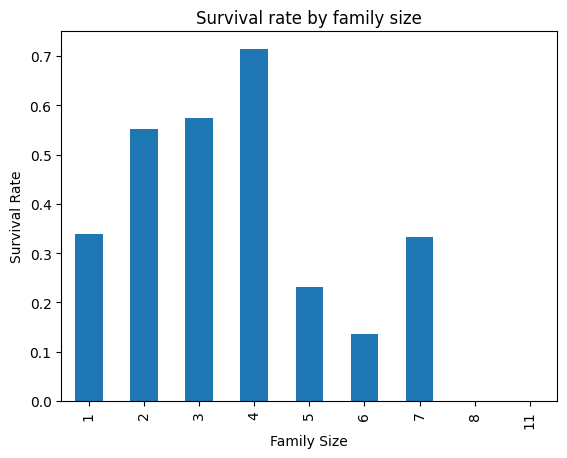

In [30]:
survival_by_family.plot(kind="bar")
plt.xlabel("Family Size")
plt.ylabel("Survival Rate")
plt.title("Survival rate by family size")
plt.show()

In [31]:
# Best size = 4
# Worst size = 6

Q7:Analyze survival rate by who column. Create is_child (age < 18). Compare who column's 'child' with is_child. Report discrepancies. Who was classified as child by age but not by who?Survival by who → Create is_child → Compare with who → Find mismatches → Report

In [32]:
survival_by_who = titanic.groupby('who')['survived'].mean()
print(survival_by_who)

who
child    0.585366
man      0.188341
woman    0.756972
Name: survived, dtype: float64


In [33]:
titanic['is_child'] = titanic['age'] < 18

In [34]:
mismatches = titanic[
    titanic['is_child'] != (titanic['who'] == 'child')
]

In [35]:
print(mismatches[['age', 'sex', 'who', 'is_child']])

      age     sex    who  is_child
68   17.0  female  woman      True
71   16.0  female  woman      True
84   17.0  female  woman      True
86   16.0    male    man      True
114  17.0  female  woman      True
138  16.0    male    man      True
156  16.0  female  woman      True
163  17.0    male    man      True
208  16.0  female  woman      True
220  16.0    male    man      True
266  16.0    male    man      True
282  16.0    male    man      True
307  17.0  female  woman      True
329  16.0  female  woman      True
333  16.0    male    man      True
389  17.0  female  woman      True
433  17.0    male    man      True
504  16.0  female  woman      True
532  17.0    male    man      True
550  17.0    male    man      True
574  16.0    male    man      True
721  17.0    male    man      True
746  16.0    male    man      True
764  16.0    male    man      True
781  17.0  female  woman      True
791  16.0    male    man      True
841  16.0    male    man      True
853  16.0  female  w

In [36]:
special_case = titanic[
    (titanic['is_child']) &
    (titanic['who'] != 'child')
]
special_case

,survived,pclass,sex,age,sibsp,parch,fare,embarked,class,who,adult_male,embark_town,alive,alone,deck_known,family_size,is_alone,is_child
68,1,3,female,17.0,4,2,7.9250,S,Third,woman,False,Southampton,yes,False,True,7,False,True
71,0,3,female,16.0,5,2,46.9000,S,Third,woman,False,Southampton,no,False,True,8,False,True
84,1,2,female,17.0,0,0,10.5000,S,Second,woman,False,Southampton,yes,True,True,1,True,True
86,0,3,male,16.0,1,3,34.3750,S,Third,man,True,Southampton,no,False,True,5,False,True
114,0,3,female,17.0,0,0,14.4583,C,Third,woman,False,Cherbourg,no,True,True,1,True,True
138,0,3,male,16.0,0,0,9.2167,S,Third,man,True,Southampton,no,True,True,1,True,True
156,1,3,female,16.0,0,0,7.7333,Q,Third,woman,False,Queenstown,yes,True,True,1,True,True
163,0,3,male,17.0,0,0,8.6625,S,Third,man,True,Southampton,no,True,True,1,True,True
208,1,3,female,16.0,0,0,7.7500,Q,Third,woman,False,Queenstown,yes,True,True,1,True,True
220,1,3,male,16.0,0,0,8.0500,S,Third,man,True,Southampton,yes,True,True,1,True,True


Q8:Create fare_per_person = fare / family_size. Create fare brackets for both fare and fare_per_person. Calculate survival rate by both. Identify passengers who appear "rich" by total fare but "poor" by per-person fare. Show 3 examples.Create fare_per_person → Create bins → Calculate survival rates → Find mismatched passengers → Show 3 examplesPart 4: GroupBy & Aggregation Analysis QuestionTaskAction Required

In [37]:
titanic['fare_per_person'] = titanic['fare'] / titanic['family_size']
print(titanic[['fare', 'family_size', 'fare_per_person']].head())

      fare  family_size  fare_per_person
0   7.2500            2          3.62500
1  71.2833            2         35.64165
2   7.9250            1          7.92500
3  53.1000            2         26.55000
4   8.0500            1          8.05000


In [38]:
titanic['fare_bracket'] = pd.qcut(titanic['fare'], 4)
titanic['fare_per_person_bracket'] = pd.qcut(titanic['fare_per_person'], 4)

In [39]:
print(titanic.groupby('fare_bracket')['survived'].mean())

fare_bracket
(-0.001, 8.05]       0.234742
(8.05, 15.9]         0.359551
(15.9, 34.198]       0.455959
(34.198, 512.329]    0.615385
Name: survived, dtype: float64


In [40]:
print(titanic.groupby('fare_per_person_bracket')['survived'].mean())

fare_per_person_bracket
(-0.001, 7.25]     0.290000
(7.25, 8.75]       0.294737
(8.75, 26.0]       0.424242
(26.0, 512.329]    0.649215
Name: survived, dtype: float64


In [41]:
examples = titanic[
    (titanic['fare_bracket'] == titanic['fare_bracket'].cat.categories[-1]) &
    (titanic['fare_per_person_bracket'] == titanic['fare_per_person_bracket'].cat.categories[0])
]

In [42]:

print("3 mismatched examples:")
print(examples[['fare', 'family_size', 'fare_per_person', 'pclass']].head(3))

3 mismatched examples:
       fare  family_size  fare_per_person  pclass
50  39.6875            6         6.614583       3
59  46.9000            8         5.862500       3
71  46.9000            8         5.862500       3


Q9:Group by sex and pclass.Calculate survival rate and count.Create grouped bar chart. Which class had highest survival for males? Which class had lowest survival for females? Explain

In [43]:
group_stats = titanic.groupby(['sex', 'pclass'])['survived'].agg(['mean', 'count'])
print(group_stats)

                   mean  count
sex    pclass                 
female 1       0.967742     93
       2       0.917808     73
       3       0.472441    127
male   1       0.369748    119
       2       0.184783     92
       3       0.160000    275


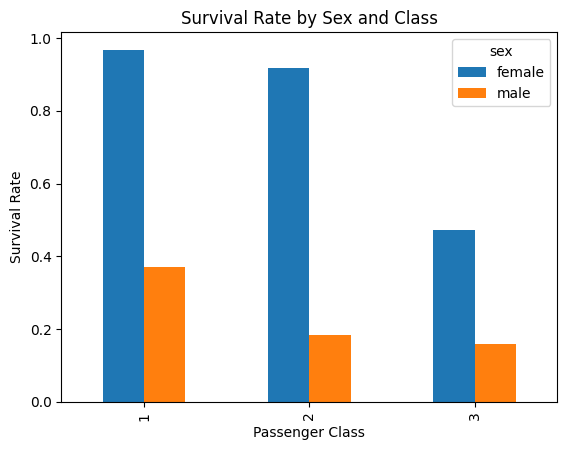

In [44]:
pivot_survival = titanic.pivot_table(
    values='survived',
    index='pclass',
    columns='sex',
    aggfunc='mean'
)

pivot_survival.plot(kind='bar')
plt.xlabel("Passenger Class")
plt.ylabel("Survival Rate")
plt.title("Survival Rate by Sex and Class")
plt.show()

In [ ]:
# Males has highest survival rate in 1st class.
# Females has lowest survival rate in 3rd class.

Q10:Calculate survival rate by embark_town alone. Then calculate by embark_town AND pclass. Calculate class distribution by embarkation port. Is survival difference due to port itself or class composition? Support with numbers.Survival by town → Survival by town + class → Class distribution by port → Compare → Conclude with numbers

In [45]:
survival_by_port = titanic.groupby('embark_town')['survived'].mean()
print(survival_by_port)

embark_town
Cherbourg      0.580645
Queenstown     0.338983
Southampton    0.375221
Name: survived, dtype: float64


In [46]:
survival_port_class = titanic.groupby(
    ['embark_town', 'pclass']
)['survived'].mean()

print(survival_port_class)

embark_town  pclass
Cherbourg    1         0.698795
             2         0.529412
             3         0.418182
Queenstown   1         0.500000
             2         0.666667
             3         0.314815
Southampton  1         0.590551
             2         0.503448
             3         0.218430
Name: survived, dtype: float64


In [47]:
class_distribution = pd.crosstab(
    titanic['embark_town'],
    titanic['pclass'],
    normalize='index'
)

print("Class distribution by port:")
print(class_distribution)

Class distribution by port:
pclass              1         2         3
embark_town                              
Cherbourg    0.535484  0.109677  0.354839
Queenstown   0.033898  0.050847  0.915254
Southampton  0.224779  0.256637  0.518584


Q11:Group by alone and calculate survival rate. Then group by family_size and calculate survival rate. Create line plot. Find optimal family size (highest survival) and worst family size (lowest survival). Explain why alone OR large family reduced survival.Groupby alone → Survival rate → Groupby family_size → Survival rate → Line plot → Find best/worst → Explain reasonsPart 5: Visualization & Correlation QuestionTaskAction Required

In [48]:
print(titanic.groupby('alone')['survived'].mean())

alone
False    0.511834
True     0.337868
Name: survived, dtype: float64


In [49]:
survival_family = titanic.groupby('family_size')['survived'].mean()
print("\nSurvival by family size:\n")
print(survival_family)


Survival by family size:

family_size
1     0.337868
2     0.551948
3     0.574257
4     0.714286
5     0.230769
6     0.136364
7     0.333333
8     0.000000
11    0.000000
Name: survived, dtype: float64


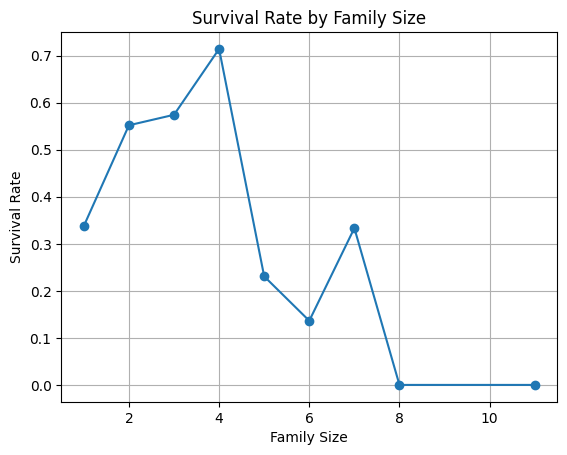

In [50]:
survival_family.plot(marker='o')
plt.xlabel("Family Size")
plt.ylabel("Survival Rate")
plt.title("Survival Rate by Family Size")
plt.grid(True)
plt.show()

Q12:Create age bins (0-10, 10-20, 20-30, 30-40, 40-50, 50-60, 60-70, 70-80). Calculate survival rate per bin. Create line plot. Create overlayed histogram of survivors vs non-survivors by age. Which age group had highest survival? Which had lowest? Which age group did worse than expected?Create age bins → Calculate survival per bin → Line plot → Overlayed histogram → Identify highest/lowest → Find unexpected grou.

In [51]:
bins = [0,10,20,30,40,50,60,70,80]
labels = ['0-10','10-20','20-30','30-40','40-50','50-60','60-70','70-80']

titanic['age_bin'] = pd.cut(
    titanic['age'],
    bins=bins,
    labels=labels,
    right=False
)

In [52]:
survival_by_age = titanic.groupby('age_bin')['survived'].mean()
print(survival_by_age)

age_bin
0-10     0.606557
10-20    0.422680
20-30    0.368421
30-40    0.458599
40-50    0.386364
50-60    0.404255
60-70    0.333333
70-80    0.000000
Name: survived, dtype: float64


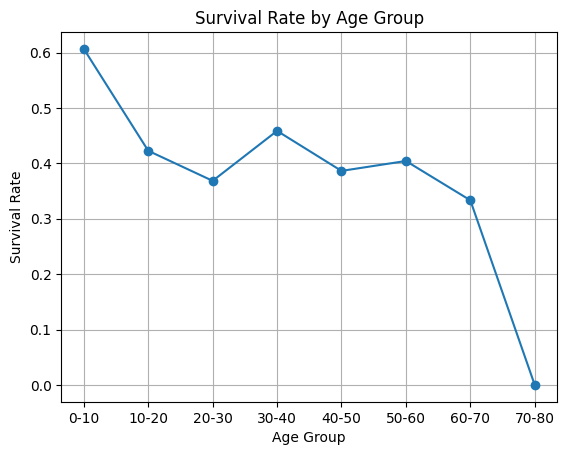

In [53]:
survival_by_age.plot(marker='o')
plt.xlabel("Age Group")
plt.ylabel("Survival Rate")
plt.title("Survival Rate by Age Group")
plt.grid(True)
plt.show()

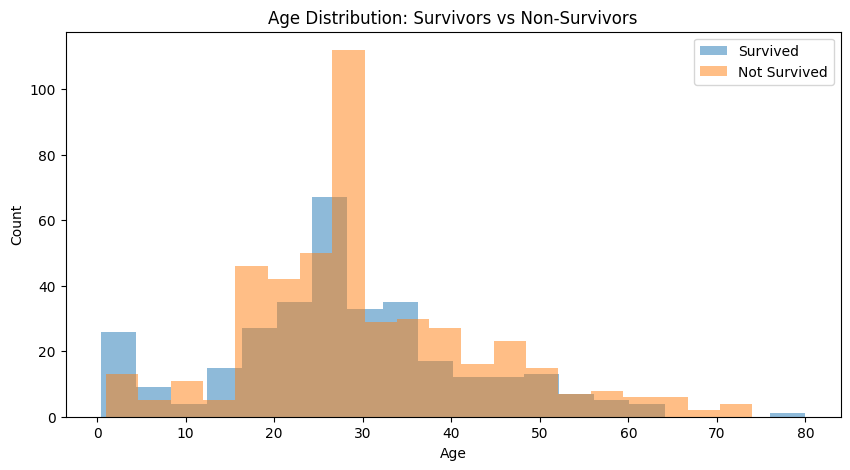

In [54]:
plt.figure(figsize=(10,5))

plt.hist(
    titanic[titanic['survived']==1]['age'],
    bins=20,
    alpha=0.5,
    label='Survived'
)

plt.hist(
    titanic[titanic['survived']==0]['age'],
    bins=20,
    alpha=0.5,
    label='Not Survived'
)

plt.xlabel("Age")
plt.ylabel("Count")
plt.title("Age Distribution: Survivors vs Non-Survivors")
plt.legend()
plt.show()

Q13:Select only numeric columns. Calculate correlation matrix. Create heatmap. Identify top 3 strongest correlations with survived. Find two features highly correlated with each other (not involving survival). What does this tell you?Select numeric columns → Correlation matrix → Heatmap → Top 3 with survived → Find pair correlated → Interpret

In [55]:
numeric_df = titanic.select_dtypes(include=['number', 'bool'])
print(numeric_df.columns)

Index(['survived', 'pclass', 'age', 'sibsp', 'parch', 'fare', 'adult_male',
       'alone', 'deck_known', 'family_size', 'is_alone', 'is_child',
       'fare_per_person'],
      dtype='str')


In [57]:
corr_matrix = numeric_df.corr()
print(corr_matrix)

                 survived    pclass       age     sibsp     parch      fare  \
survived         1.000000 -0.331448 -0.077100 -0.038194  0.069175  0.247000   
pclass          -0.331448  1.000000 -0.341432  0.088291  0.040335 -0.551719   
age             -0.077100 -0.341432  1.000000 -0.279149 -0.182627  0.092358   
sibsp           -0.038194  0.088291 -0.279149  1.000000  0.380385  0.134722   
parch            0.069175  0.040335 -0.182627  0.380385  1.000000  0.191613   
fare             0.247000 -0.551719  0.092358  0.134722  0.191613  1.000000   
adult_male      -0.528808  0.067541  0.272698 -0.272487 -0.345537 -0.164690   
alone           -0.175088  0.110564  0.189999 -0.608568 -0.570149 -0.246334   
deck_known            NaN       NaN       NaN       NaN       NaN       NaN   
family_size      0.013337  0.079656 -0.282248  0.860006  0.799058  0.193311   
is_alone        -0.175088  0.110564  0.189999 -0.608568 -0.570149 -0.246334   
is_child         0.108780  0.156197 -0.608971  0.392

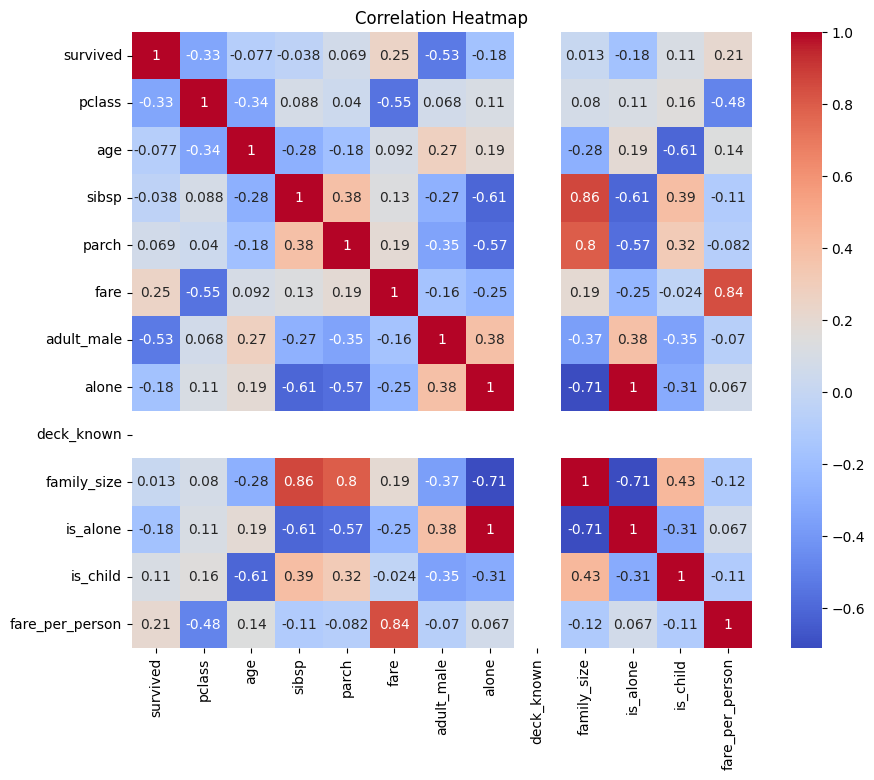

In [58]:
plt.figure(figsize=(10,8))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm')
plt.title("Correlation Heatmap")
plt.show()

In [61]:
# top 3 strongest with survival
top_survival_corr = corr_matrix['survived'].drop('survived').abs().sort_values(ascending=False)
print(top_survival_corr.head(3))

adult_male    0.528808
pclass        0.331448
fare          0.247000
Name: survived, dtype: float64


In [ ]:
# Highest correlated
print(corr_matrix.loc['sibsp', 'family_size'])

0.8600059899110006


Q14:Based on your analysis, identify top 3 factors influencing survival. Create survival_score additive score. Find combination with HIGHEST survival rate. Find combination with LOWEST survival rate. Create pivot table of survival rate by top two categorical factors. Write executive summary.Identify top 3 factors → Create additive score → Find highest combo → Find lowest combo → Pivot table → Write summary 

In [ ]:
# Top 3 factors influencing survival

# Based on all previous analysis, the strongest factors are:

# ⭐ Top 3
# Sex / gender role
# females survived much more
# Passenger class
# 1st class highest
# Age group
# children highest survival

In [62]:
titanic['survival_score'] = 0

titanic['survival_score'] += (titanic['sex'] == 'female') * 2
titanic['survival_score'] += (titanic['pclass'] == 1) * 2
titanic['survival_score'] += (titanic['age'] < 18) * 1

In [63]:
score_survival = titanic.groupby('survival_score')['survived'].mean()
print(score_survival)

survival_score
0    0.133333
1    0.365385
2    0.509294
3    0.680000
4    0.976471
5    0.875000
Name: survived, dtype: float64


In [64]:
best_combo = titanic[
    (titanic['sex'] == 'female') &
    (titanic['pclass'] == 1) &
    (titanic['age'] < 18)
]

print(best_combo['survived'].mean())

0.875


In [65]:
worst_combo = titanic[
    (titanic['sex'] == 'male') &
    (titanic['pclass'] == 3) &
    (titanic['age'] >= 18)
]

print(worst_combo['survived'].mean())

0.1452991452991453


In [66]:
pivot_table = titanic.pivot_table(
    values='survived',
    index='pclass',
    columns='sex',
    aggfunc='mean'
)

print(pivot_table)

sex       female      male
pclass                    
1       0.967742  0.369748
2       0.917808  0.184783
3       0.472441  0.160000


In [ ]:
# Summary

# The top three factors influencing survival were gender, passenger class, and age group. Females, first-class 
# passengers, and children had significantly higher survival rates.
# A simple additive survival_score combining these factors showed a clear monotonic relationship with survival 
# probability.
# The highest survival combination was female + first class + child, while the lowest survival combination was adult 
# male + third class.
# The pivot table of sex × pclass further confirmed that gender and class jointly explain most survival differences.